# Lab: Implementing Linear and Logistic Regression from Scratch

## Learning Objectives

1. implement linear regression from scratch
2. implement logistic regression from scratch
3. compute predictions, losses, and gradients
4. train both models using gradient descent
5. compare regression and classification

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X_raw = np.array([[1.0],
                  [2.0],
                  [3.0],
                  [4.0],
                  [5.0]])

y = np.array([3.0, 5.0, 7.0, 9.0, 11.0])  # y = 2x + 1

X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

# Part 1: Linear Regression

Linear regression predicts a continuous output.

Given a feature matrix $X \in \mathbb{R}^{m \times n}$ and parameter vector $\mathbf{w} \in \mathbb{R}^{n}$, the model prediction is

$$
\hat{\mathbf{y}} = X\mathbf{w}
$$

where:

- $m$ is the number of training examples
- $n$ is the number of features (including the bias term if used)
- $\hat{\mathbf{y}}$ is the vector of predictions

In [9]:
def predict_linear(X, w):
    return np.dot(X,w)

## Mean Squared Error Loss

We use mean squared error (MSE) as the loss function:

$$
J(\mathbf{w}) = \frac{1}{2m}\sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)^2
$$

where:

- $\hat{y}^{(i)}$ is the prediction for example $i$
- $y^{(i)}$ is the true target value for example $i$

The factor $\frac{1}{2}$ is included for convenience when taking derivatives.

In [10]:
def compute_mse(X, y, w):
    m = len(y)
    y_hat = #A function we wrote
    return #formula

## Gradient for Linear Regression

The gradient of the loss with respect to the parameter vector $\mathbf{w}$ is

$$
\nabla J(\mathbf{w}) = \frac{1}{m}X^T(X\mathbf{w} - \mathbf{y})
$$

This tells us the direction of steepest increase of the loss, so gradient descent updates the parameters in the opposite direction.

In [57]:
def compute_linear_gradient(X, y, w):
    m = len(y)
    y_hat = predict_linear(X, w)
    return (1 / m) * np.dot(X.T, (y_hat - y))

## Gradient Descent Update Rule

At each iteration, we update the parameters using

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \nabla J(\mathbf{w})
$$

where $\alpha$ is the learning rate.

In [12]:
def train_linear_regression(X, y, lr=0.01, epochs=1000):
    w = np.zeros(X.shape[1])
    history = []

    for epoch in range(epochs):
        grad = #Call a function we wrote
        w = #A Formula
        history.append(compute_mse(X, y, w))

    return w, history

In [13]:
w_lin, lin_history = train_linear_regression(X, y, lr=0.01, epochs=5000)

print("Learned weights:", w_lin)
print("Final loss:", lin_history[-1])

Learned weights: [0.99991223 2.00002431]
Final loss: 7.010213676939787e-10


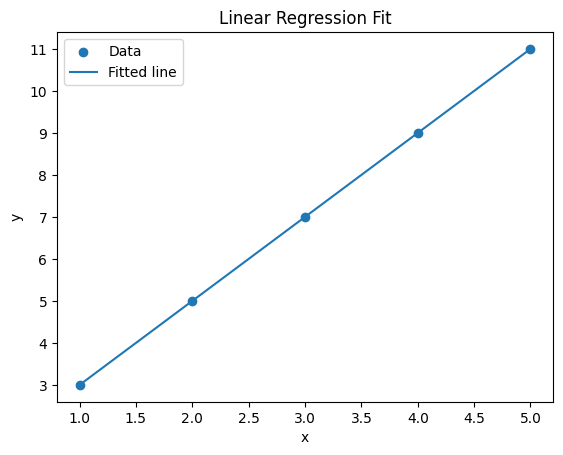

In [14]:
plt.scatter(X_raw, y, label="Data")
plt.plot(X_raw, predict_linear(X, w_lin), label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()

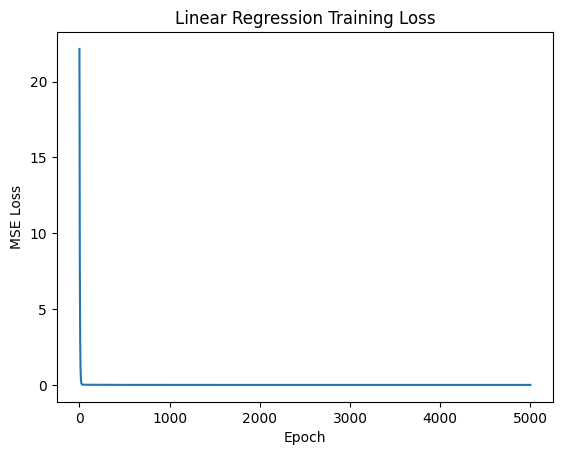

In [15]:
plt.plot(lin_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear Regression Training Loss")
plt.show()

# Part 2: Logistic Regression

Logistic regression predicts the probability of a binary class.

First, we compute a linear score:

$$
z = X\mathbf{w}
$$

Then we pass it through the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability is

$$
\hat{\mathbf{y}} = \sigma(X\mathbf{w})
$$

where each prediction is a value between 0 and 1.

In [16]:
X_raw = np.array([[1.0],
                  [2.0],
                  [3.0],
                  [4.0],
                  [5.0],
                  [6.0]])

y = np.array([0, 0, 0, 1, 1, 1])

X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

In [17]:
def sigmoid(z):
    return #Sigmoid Formula

def predict_logistic_prob(X, w):
    return #Prediction

## Binary Cross-Entropy Loss

For logistic regression, we use binary cross-entropy loss:

$$
J(\mathbf{w}) = -\frac{1}{m}\sum_{i=1}^{m} \left[
y^{(i)}\log\left(\hat{y}^{(i)}\right) + (1-y^{(i)})\log\left(1-\hat{y}^{(i)}\right)
\right]
$$

This loss is appropriate for binary classification because it strongly penalizes confident incorrect predictions.

In [18]:
def compute_bce(X, y, w):
    m = len(y)
    y_hat = predict_logistic_prob(X, w)
    eps = 1e-12
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return #A formula

## Gradient for Logistic Regression

The gradient of the logistic regression loss is

$$
\nabla J(\mathbf{w}) = \frac{1}{m}X^T(\hat{\mathbf{y}} - \mathbf{y})
$$

This looks very similar to linear regression, but here $\hat{\mathbf{y}}$ is produced by the sigmoid function.

In [19]:
def compute_logistic_gradient(X, y, w):
    m = len(y)
    y_hat = predict_logistic_prob(X, w)
    return #A formula

## Converting Probabilities to Class Predictions

After computing predicted probabilities, we convert them to class labels using a threshold, usually 0.5:

$$
\hat{y}^{(i)} =
\begin{cases}
1 & \text{if } p^{(i)} \geq 0.5 \\
0 & \text{if } p^{(i)} < 0.5
\end{cases}
$$

In [20]:
#I'm just going to give this to you
def predict_logistic_class(X, w, threshold=0.5):
    probs = predict_logistic_prob(X, w)
    return (probs >= threshold).astype(int)

In [21]:
def train_logistic_regression(X, y, lr=0.1, epochs=5000):
    w = np.zeros(X.shape[1])
    history = []

    for epoch in range(epochs):
        grad = compute_logistic_gradient(X, y, w)
        w = w - lr * grad
        history.append(compute_bce(X, y, w))

    return w, history

In [22]:
w_log, log_history = train_logistic_regression(X, y, lr=0.1, epochs=5000)

print("Learned weights:", w_log)
print("Final loss:", log_history[-1])

probs = predict_logistic_prob(X, w_log)
preds = predict_logistic_class(X, w_log)

print("Probabilities:", probs)
print("Predictions:", preds)
print("Accuracy:", np.mean(preds == y))

Learned weights: [-11.09902191   3.2208467 ]
Final loss: 0.0642149884370227
Probabilities: [3.78780356e-04 9.40253898e-03 1.92090754e-01 8.56235007e-01
 9.93341707e-01 9.99732483e-01]
Predictions: [0 0 0 1 1 1]
Accuracy: 1.0


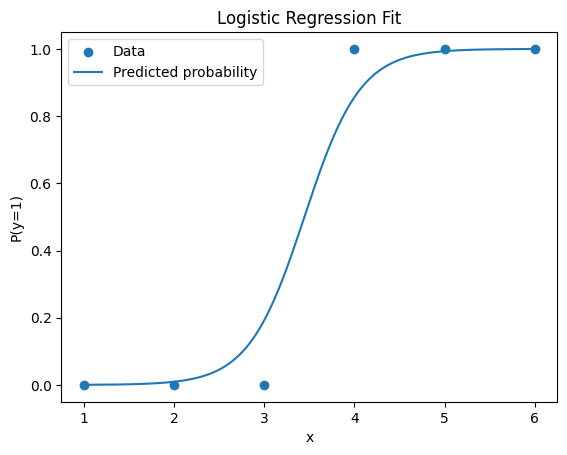

In [23]:
x_plot = np.linspace(1, 6, 200).reshape(-1, 1)
X_plot = np.hstack([np.ones((x_plot.shape[0], 1)), x_plot])
y_plot = predict_logistic_prob(X_plot, w_log)

plt.scatter(X_raw, y, label="Data")
plt.plot(x_plot, y_plot, label="Predicted probability")
plt.xlabel("x")
plt.ylabel("P(y=1)")
plt.title("Logistic Regression Fit")
plt.legend()
plt.show()

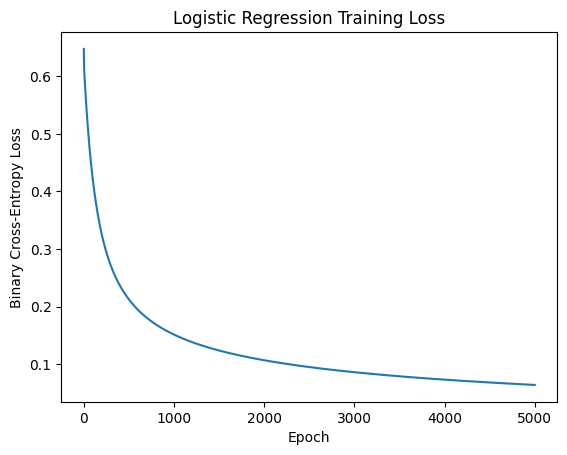

In [24]:
plt.plot(log_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.show()

In [25]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# Part : Multiclass Classification on MNIST

In this section, you will extend logistic regression from binary classification to multiclass classification.

MNIST contains handwritten digits from 0 through 9, so there are 10 possible classes.

For multiclass logistic regression, we use the **softmax** function instead of the sigmoid function.

If the score vector for one example is

$$
\mathbf{z} = [z_1, z_2, \dots, z_{10}]
$$

then the softmax output for class $j$ is

$$
\text{softmax}(z_j) = \frac{e^{z_j}}{\sum_{k=1}^{10} e^{z_k}}
$$

This converts the raw scores into probabilities that sum to 1.

The model prediction is

$$
\hat{Y} = \text{softmax}(XW)
$$

where:

- $X \in \mathbb{R}^{m \times n}$ is the feature matrix
- $W \in \mathbb{R}^{n \times 10}$ is the parameter matrix
- $\hat{Y} \in \mathbb{R}^{m \times 10}$ contains the predicted class probabilities

In [35]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

## Load and Preprocess MNIST

We will do the preprocessing for you.

Steps:
1. load MNIST
2. convert the labels to integers
3. scale pixel values to the range $[0,1]$
4. split into training and test sets
5. add a bias column of ones

In [36]:
# Load MNIST
X_all, y_all = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

# Convert labels to integers
y_all = y_all.astype(int)

# Scale pixels to [0, 1]
X_all = X_all / 255.0

# Optional: use a subset so scratch training runs faster
subset_size = 15000
X_all = X_all[:subset_size]
y_all = y_all[:subset_size]

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Add bias column
X_train = np.hstack([np.ones((X_train_raw.shape[0], 1)), X_train_raw])
X_test = np.hstack([np.ones((X_test_raw.shape[0], 1)), X_test_raw])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12000, 785)
X_test shape: (3000, 785)
y_train shape: (12000,)
y_test shape: (3000,)


## Visualize Sample Images

Before training, it is useful to inspect a few examples from the dataset.

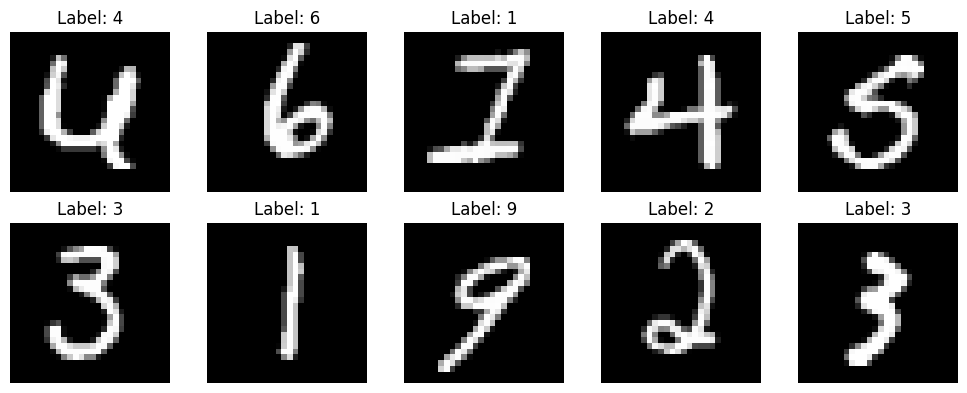

In [37]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## One-Hot Labels and Cross-Entropy Loss

For multiclass classification, the labels are converted into **one-hot vectors**.

For example, if the digit is 3, then the one-hot label is

$$
[0,0,0,1,0,0,0,0,0,0]
$$

The categorical cross-entropy loss is

$$
J(W) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{10} Y_{ij}\log(\hat{Y}_{ij})
$$

where:

- $Y$ is the one-hot encoded true label matrix
- $\hat{Y}$ is the predicted probability matrix

In [38]:
def one_hot_encode(y, num_classes=10):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y] = 1
    return Y

In [39]:
Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Y_train shape: (12000, 10)
Y_test shape: (3000, 10)


## Gradient for Softmax Regression

The gradient of the loss with respect to the parameter matrix $W$ is

$$
\nabla J(W) = \frac{1}{m} X^T(\hat{Y} - Y)
$$

This is very similar in form to the binary logistic regression gradient, but now the outputs are vectors instead of single probabilities.

In [41]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

## Prediction Function

The model computes a matrix of class scores:

$$
XW
$$

and then applies softmax to get class probabilities:

$$
\hat{Y} = \text{softmax}(XW)
$$

In [47]:
def predict_softmax_prob(X, W):
    scores = np.dot(X, W)
    return softmax(scores)

## Categorical Cross-Entropy Loss

For multiclass classification, we use categorical cross-entropy loss:

$$
J(W) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{j=1}^{10} Y_{ij}\log(\hat{Y}_{ij})
$$

where:

- $Y$ is the one-hot encoded true label matrix
- $\hat{Y}$ is the predicted probability matrix

In [48]:
def compute_categorical_cross_entropy(X, Y, W):
    m = X.shape[0]
    Y_hat = predict_softmax_prob(X, W)
    eps = 1e-12
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return -(1 / m) * np.sum(Y * np.log(Y_hat))

## Gradient for Softmax Regression

The gradient of the loss with respect to the parameter matrix $W$ is

$$
\nabla J(W) = \frac{1}{m} X^T(\hat{Y} - Y)
$$

This is the quantity used in gradient descent.

In [49]:
def compute_softmax_gradient(X, Y, W):
    m = X.shape[0]
    Y_hat = predict_softmax_prob(X, W)
    return (1 / m) * np.dot(X.T, (Y_hat - Y))

## Class Prediction

Once we have class probabilities, we predict the class with the largest probability.

$$
\hat{y}^{(i)} = \arg\max_j \hat{Y}_{ij}
$$

In [50]:
def predict_softmax_class(X, W):
    probs = predict_softmax_prob(X, W)
    return np.argmax(probs, axis=1)

## Training Loop

We initialize the parameter matrix $W$ to zeros and repeatedly update it using gradient descent:

$$
W \leftarrow W - \alpha \nabla J(W)
$$

where $\alpha$ is the learning rate.

In [51]:
def train_softmax_regression(X, Y, lr=0.5, epochs=300):
    W = np.zeros((X.shape[1], Y.shape[1]))
    history = []

    for epoch in range(epochs):
        grad = compute_softmax_gradient(X, Y, W)
        W = W - lr * grad
        history.append(compute_categorical_cross_entropy(X, Y, W))

    return W, history

## Train the Model on MNIST

Now use your implementation to train multiclass logistic regression on MNIST.

In [52]:
W_mnist, mnist_history = train_softmax_regression(X_train, Y_train, lr=0.5, epochs=300)

print("Final training loss:", mnist_history[-1])

Final training loss: 0.3032469313906394


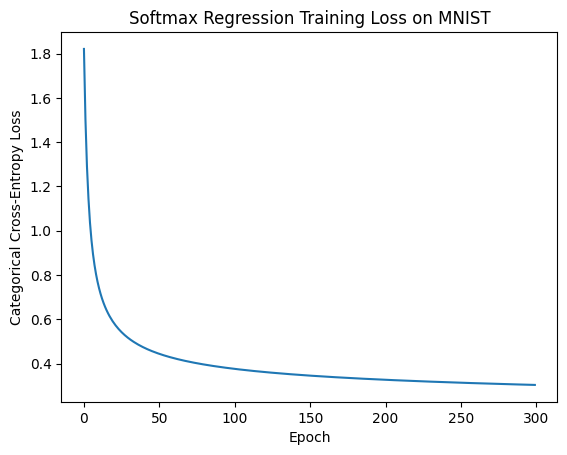

In [53]:
plt.plot(mnist_history)
plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("Softmax Regression Training Loss on MNIST")
plt.show()

In [54]:
test_preds = predict_softmax_class(X_test, W_mnist)
test_accuracy = np.mean(test_preds == y_test)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.902


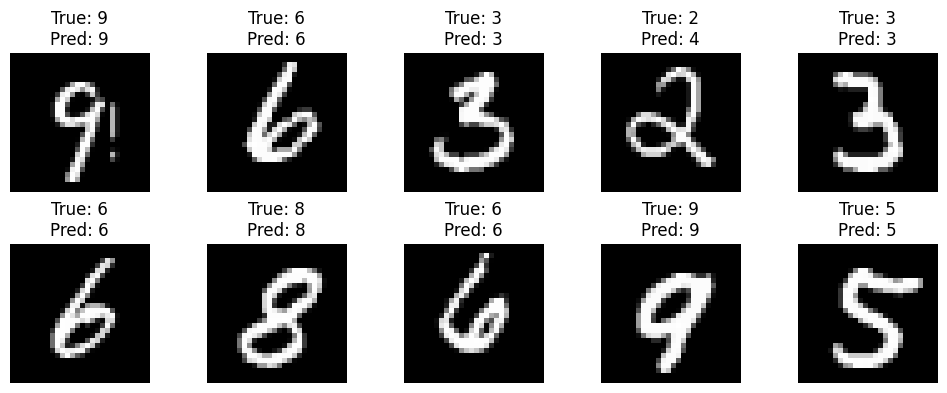

In [55]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_raw[i].reshape(28, 28), cmap="gray")
    pred = test_preds[i]
    true = y_test[i]
    ax.set_title(f"True: {true}\nPred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Inspect the Predicted Probability Distribution for One Example

For a single image, the model produces a probability for each of the 10 classes.

In [56]:
sample_index = 0
sample_probs = predict_softmax_prob(X_test[sample_index:sample_index+1], W_mnist)[0]

print("True label:", y_test[sample_index])
print("Predicted label:", np.argmax(sample_probs))
print("Probabilities:", sample_probs)

True label: 9
Predicted label: 9
Probabilities: [6.67962283e-05 2.26851379e-04 3.37890067e-04 9.70061880e-03
 4.25979869e-02 1.94939349e-02 6.44789109e-04 2.59960282e-02
 5.18750128e-02 8.49060092e-01]
